In [2]:
import gymnasium as gym
env = gym.make("CartPole-v1",render_mode="human")
obs,info = env.reset()
print(obs,obs.shape,info)
action = env.action_space.sample()
obs,reward,terminated,truncated,info = env.step(action)
done = terminated or truncated
#terminated - epizod skonczony, np. kij upadl poza rog
# truncated - epizod uciety - limit czasu/krokow
# done = terminated or truncated - do petli

print(env.observation_space)



#3!
print(env.action_space)
print("obs_dim=", env.observation_space.shape[0])
print("n_actions =", env.action_space.n)
#action - dwie , observation space - 4dim

#4!
obs,info = env.reset()
total = 0
for t in range(500):
    action = env.action_space.sample()
    obs,reward,terminated,truncated, info = env.step(action)
    total+=reward
    if terminated or truncated:
        break
print("return =", total,  "steps =", t+1)
env.close()

#x - polozenie wozka, dot{x} - predkosc wozka, theta - kat drazka wzgledem pionu, dot{theta} - predkosc katowa drazka
#rgb_array 
#
env = gym.make("CartPole-v1", render_mode = "rgb_array")
obs,info=env.reset()
frame = env.render()
print(frame.shape)
env.close()

#5!
#A
env = gym.make("CartPole-v1",render_mode="human")
obs,info = env.reset()
for _ in range(200):
    action = env.action_space.sample()
    obs,reward,terminated,truncated, info = env.step(action)
    if terminated or truncated:
        obs,info = env.reset()
env.close()
#B
env = gym.make("CartPole-v1", render_mode="rgb_array")
obs,info = env.reset()
frame = env.render()
print(frame.shape)
env.close()

#6!
obs,info = env.reset(seed=0)
env.action_space.seed(0)


<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/piotr/anaconda3/envs/frozenlake-rl/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


[ 0.01181322 -0.01252468  0.00972156  0.0400601 ] (4,) {}
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Discrete(2)
obs_dim= 4
n_actions = 2
return = 14.0 steps = 14
(400, 600, 3)
(400, 600, 3)


0

## Ćwiczenie: “czytanie stanu” CartPole na żywo (bez uczenia)

W CartPole obserwacja to wektor:

\[
s=(x,\dot x,\theta,\dot\theta)
\]

- \(x\): położenie wózka (lewo/prawo)
- \(\dot x\): prędkość wózka
- \(\theta\): kąt kija względem pionu (0 = pion)
- \(\dot\theta\): prędkość kątowa (jak szybko kij “ucieka”)

### Jak interpretować sytuację?
Kluczowa jest para \((\theta,\dot\theta)\):

- jeśli \(\theta\cdot \dot\theta > 0\) ⇒ kij **ucieka dalej** (pogarsza się)
- jeśli \(\theta\cdot \dot\theta < 0\) ⇒ kij **wraca / hamuje przechył** (lepiej)

### Zadanie
1. Uruchom kod poniżej.
2. Obserwuj wydruki co 10 kroków.
3. Zwróć uwagę na sytuacje, gdy \(\theta>0\) i \(\dot\theta>0\) (oraz analogicznie dla ujemnych).
## Pytania (odpowiedz krótko)

1) Co się dzieje z epizodem, gdy \(|\theta|\) zaczyna rosnąć i \(\theta\cdot\dot\theta>0\)?

2) Jeśli w pewnym momencie widzisz:
- \(\theta>0\) i \(\dot\theta>0\)

to **jaka akcja** (0=lewo, 1=prawo) wydaje Ci się intuicyjnie sensowna, żeby “podjechać pod kij” — i dlaczego?

3) Analogicznie: co byś zrobił dla \(\theta<0\) i \(\dot\theta<0\)?


In [1]:
#losowa polityka
import gymnasium as gym
env = gym.make("CartPole-v1")
obs,info = env.reset(seed=0)
for t in range(200):
    x,xdot,th,thdot = obs

    if t%10==0:
        print(f"={t:3d} | x={x:+.3f} xdot={xdot:+3f} theta={th:+.3f} thetadot={thdot:+.3f}")
        if th * thdot > 0:
            print("   -> kij ucieka dalej (pogarsza się): theta i thetadot mają ten sam znak")
        elif th * thdot < 0:
            print("   -> kij wraca / hamuje przechył: theta i thetadot mają przeciwne znaki")
        else:
            print("   -> granicznie: theta*thetadot = 0 (rzadko)")
    action = env.action_space.sample()

    obs,reward,terminated,truncated,info = env.step(action)

    done = terminated or truncated

    if done:
        obs,info = env.reset()

#sredni return heurystyka
import gymnasium as gym
import numpy as np

def run_policy(policy_fn, episodes=20, seed=0):
    env = gym.make("CartPole-v1")
    rets = []
    for ep in range(episodes):
        obs, info = env.reset(seed=seed+ep)
        total = 0
        while True:
            action = policy_fn(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            total += reward
            if terminated or truncated:
                break
        rets.append(total)
    env.close()
    return np.mean(rets), np.std(rets), rets

# 1) random
mean_r, std_r, _ = run_policy(lambda obs: np.random.randint(0,2), episodes=30)
print("RANDOM   mean±std:", mean_r, std_r)

# 2) heuristic: push towards the tilt
def heuristic(obs):
    x, xdot, th, thdot = obs
    return 1 if th > 0 else 0

mean_h, std_h, _ = run_policy(heuristic, episodes=30)
print("HEURISTIC mean±std:", mean_h, std_h)

        

=  0 | x=+0.014 xdot=-0.023021 theta=-0.046 thetadot=-0.048
   -> kij ucieka dalej (pogarsza się): theta i thetadot mają ten sam znak
= 10 | x=+0.029 xdot=-0.012448 theta=-0.102 thetadot=-0.283
   -> kij ucieka dalej (pogarsza się): theta i thetadot mają ten sam znak
= 20 | x=+0.001 xdot=+0.003371 theta=-0.149 thetadot=-0.637
   -> kij ucieka dalej (pogarsza się): theta i thetadot mają ten sam znak
= 30 | x=+0.017 xdot=+0.039231 theta=+0.044 thetadot=+0.068
   -> kij ucieka dalej (pogarsza się): theta i thetadot mają ten sam znak
= 40 | x=+0.020 xdot=+0.030711 theta=+0.078 thetadot=+0.257
   -> kij ucieka dalej (pogarsza się): theta i thetadot mają ten sam znak
= 50 | x=+0.037 xdot=+0.017401 theta=+0.136 thetadot=+0.554
   -> kij ucieka dalej (pogarsza się): theta i thetadot mają ten sam znak
= 60 | x=+0.048 xdot=+1.017781 theta=-0.030 thetadot=-1.484
   -> kij ucieka dalej (pogarsza się): theta i thetadot mają ten sam znak
= 70 | x=+0.030 xdot=-0.437518 theta=+0.028 thetadot=+0.567
  

## Co właśnie zrobiliśmy i co to znaczy (CartPole — “czytanie stanu” + prosta polityka)

### 1) Stan środowiska (obserwacja)

W CartPole obserwacja to wektor 4 liczb:

$$
s = (x,\dot x,\theta,\dot\theta)
$$

- $x$ — położenie wózka na osi
- $\dot x$ — prędkość wózka
- $\theta$ — kąt kija względem pionu (0 = pion)
- $\dot\theta$ — prędkość kątowa kija (jak szybko kąt się zmienia)

To jest (w przybliżeniu) pełny opis stanu fizycznego układu: na jego podstawie można przewidywać przyszłą dynamikę.

---

### 2) Co znaczy “kij ucieka” vs “kij wraca”

Patrzymy na parę $(\theta,\dot\theta)$.

- Jeśli $\theta \cdot \dot\theta > 0$, to znak $\theta$ i $\dot\theta$ jest taki sam:
  - kij jest przechylony w jakąś stronę ($\theta \neq 0$),
  - i jeszcze przyspiesza w tym samym kierunku,
  - czyli przechył narasta → sytuacja się pogarsza.

- Jeśli $\theta \cdot \dot\theta < 0$, to znaki są przeciwne:
  - kij jest przechylony w jedną stronę,
  - ale jego prędkość kątowa “ciągnie” go z powrotem,
  - czyli przechył hamuje → sytuacja się poprawia.

To dokładnie widzieliśmy w logach:
- często pojawia się “ucieka” (losowe akcje nie stabilizują układu),
- czasem “wraca” (bo przypadkiem trafiliśmy dobrą akcją).

---

### 3) Co to jest polityka (policy) w praktyce?

Polityka to po prostu funkcja, która bierze stan i zwraca akcję:

$$
\pi(s) \to a
$$

W teście mieliśmy dwie polityki:

#### (A) Polityka losowa

$$
\pi_{\text{rand}}(s) = \text{losuj } a \in \{0,1\}
$$

Nie używa informacji o stanie.

#### (B) Polityka heurystyczna “pchnij w stronę przechyłu”

$$
\pi_{\text{heur}}(s) =
\begin{cases}
1 & \text{gdy } \theta > 0 \\
0 & \text{gdy } \theta < 0
\end{cases}
$$

Intuicja: podjechać wózkiem pod kij.  
Jeśli kij przechyla się w prawo, jedź w prawo; jeśli w lewo, jedź w lewo.

To jest już sterowanie zależne od stanu.

##### Czym jest heurystyka?

Heurystyka to ręcznie wymyślona reguła decyzyjna (prosty “przepis”), która na podstawie stanu $s$ wybiera akcję, np.
$\theta>0 \Rightarrow a=1$, $\theta<0 \Rightarrow a=0$ — bez uczenia się z danych.

---

### 4) Co oznaczają wyniki

- RANDOM: $\text{mean} \pm \text{std}$ powinno wyjść mniej
- HEURISTIC: $\text{mean} \pm \text{std}$ powinno wyjść więcej

W CartPole nagroda jest zwykle +1 za każdy krok, więc:

$$
\text{return} \approx \text{liczba kroków do upadku}
$$

Heurystyka utrzymuje kij średnio ~39 kroków zamiast ~23.

Dlaczego heurystyka działa lepiej?  
Bo wykorzystuje najważniejszą informację ze stanu: znak $\theta$.

Dlaczego nie rozwiązuje problemu do końca?  
Bo ignoruje dynamikę:
- $\dot\theta$ mówi, czy kij już szybko “ucieka”,
- $x$ i $\dot x$ mówią, czy wózek nie zbliża się do granic.

---

### 5) Jak to łączy się z notebookami (kontekst RL)

To ćwiczenie jest mostem do RL.

#### DQN (notebooki 02/03): value-based

Uczy **funkcję wartości** akcji:

$$
Q_\theta(s,a)
$$

i wybiera akcję:

$$
a = \arg\max_a Q_\theta(s,a)
$$

Zamiast ręcznej reguły typu “jeśli $\theta>0$…”, algorytm uczy się, która akcja jest lepsza w danym stanie.

---

#### REINFORCE / A2C / PPO (04/05/06): policy-based

Uczą się bezpośrednio polityki:

$$
\pi_\theta(a \mid s)
$$

czyli rozkładu prawdopodobieństwa akcji zależnego od stanu.

To formalizacja tego, co zrobiliśmy ręcznie:

$$
\pi(s) \to a
$$

---

### 6) Najważniejsza intuicja

1. Stan $s$ to liczby opisujące fizykę układu.
2. Polityka to funkcja stanu: $s \mapsto a$.
3. Nawet bardzo prosta polityka zależna od stanu jest dużo lepsza niż losowa.
4. RL to proces automatycznego uczenia takiej funkcji (lub funkcji wartości), zamiast zgadywać reguły ręcznie.

---

### Krok dalej

Możemy ulepszyć heurystykę, np.:

$$
a = \mathbb{1}\big[\theta + c\,\dot\theta > 0\big]
$$

czyli decyzja zależy nie tylko od kąta, ale też od jego prędkości.

To jest już bardzo blisko idei liniowej funkcji:

$$
f(s) = w_1 \theta + w_2 \dot\theta
$$

a potem ogólnej funkcji aproksymującej (jak w DQN czy policy gradient).


## Ulepszona heurystyka: wykorzystanie kąta i prędkości kątowej

Wcześniej używaliśmy bardzo prostej reguły:

$$
a =
\begin{cases}
1 & \text{gdy } \theta > 0 \\
0 & \text{gdy } \theta < 0
\end{cases}
$$

To znaczy: jedź w stronę, w którą przechyla się kij.

---

## Dlaczego to nie wystarcza?

Stan zawiera też $\dot\theta$ — prędkość kątową.

- $\theta$ mówi, gdzie kij jest teraz,
- $\dot\theta$ mówi, dokąd i jak szybko zmierza.

Jeśli $\theta > 0$ i $\dot\theta > 0$, kij nie tylko jest przechylony, ale jeszcze przyspiesza w tym kierunku — sytuacja szybko się pogarsza.

Dlatego możemy spróbować bardziej “dynamicznej” reguły:

$$
u(s) = \theta + c\,\dot\theta
$$

i podjąć decyzję:

$$
a =
\begin{cases}
1 & \text{gdy } u(s) > 0 \\
0 & \text{gdy } u(s) \le 0
\end{cases}
$$

Współczynnik $c$ mówi, jak bardzo reagujemy na prędkość kątową.

- małe $c$ → prawie ignorujemy dynamikę,
- duże $c$ → mocno reagujemy na “pęd” kija.

---

## Co to znaczy matematycznie?

To już jest liniowa funkcja stanu:

$$
u(s) = w_1\,\theta + w_2\,\dot\theta
$$

gdzie:
- $w_1 = 1$,
- $w_2 = c$.

To dokładnie duch function approximation:
zamiast twardej reguły logicznej,
używamy funkcji parametrycznej.

To jest pierwszy krok w stronę:
- liniowej aproksymacji $Q_\theta(s,a)$,
- albo liniowej polityki $\pi_\theta(a|s)$.


In [3]:
import gymnasium as gym
import numpy as np

def run_policy(policy_fn, episodes=50, seed=0):
    env = gym.make("CartPole-v1")
    rets = []
    for ep in range(episodes):
        obs, info = env.reset(seed=seed+ep)
        total = 0
        while True:
            action = policy_fn(obs)
            obs, reward, terminated, truncated, info = env.step(int(action))
            total += reward
            if terminated or truncated:
                break
        rets.append(total)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))

# bazowa heurystyka (tylko theta)
def heur_theta(obs):
    x, xdot, th, thdot = obs
    return 1 if th > 0 else 0

print("theta-only  mean±std:", *run_policy(heur_theta, episodes=50, seed=0))
# * - rozpakowanie zwracanej krotki
# heurystyka theta + c*thetadot
def make_heur_theta_dot(c):
    def policy(obs):
        x, xdot, th, thdot = obs
        u = th + c * thdot
        return 1 if u > 0 else 0
    return policy

for c in [0.0, 0.1, 0.25, 0.5, 1.0]:
    mean, std = run_policy(make_heur_theta_dot(c), episodes=50, seed=0)
    print(f"c={c:>4}  mean±std: {mean:6.1f} ± {std:5.1f}")


theta-only  mean±std: 39.12 8.794634728060057
c= 0.0  mean±std:   39.1 ±   8.8
c= 0.1  mean±std:  500.0 ±   0.0
c=0.25  mean±std:  500.0 ±   0.0
c= 0.5  mean±std:  500.0 ±   0.0
c= 1.0  mean±std:  496.7 ±  23.2


## Interpretacja wyników heurystyki $u(s)=\theta + c\,\dot\theta$ (CartPole)

Twoje wyniki:

- theta-only: mean±std = $39.12 \pm 8.79$
- $c=0.0$: $39.1 \pm 8.8$
- $c=0.1$: $500.0 \pm 0.0$
- $c=0.25$: $500.0 \pm 0.0$
- $c=0.5$: $500.0 \pm 0.0$
- $c=1.0$: $496.7 \pm 23.2$

---

### 1) Co oznacza “500.0”?

W `CartPole-v1` epizod ma maksymalną długość **500 kroków** (limit czasu).  
Jeśli widzisz zwrot $500.0$, to znaczy:

> Polityka utrzymała kij przez cały epizod (pełen limit), czyli zrobiła „perfekcyjny run”.

Dlatego odchylenie standardowe wynosi $0.0$: wszystkie epizody kończyły się dokładnie na limicie.

---

### 2) Dlaczego dodanie $\dot\theta$ tak drastycznie poprawiło wynik?

Heurystyka tylko z $\theta$ reaguje “z opóźnieniem”:
- widzi, że kij już się przechyla,
- ale nie widzi, jak szybko “ucieka”.

Dodając $\dot\theta$, polityka zaczyna reagować *predykcyjnie*:
- $\dot\theta$ mówi, czy przechył będzie narastał i jak szybko.
- wyrażenie $u(s)=\theta + c\,\dot\theta$ to prosta wersja kontrolera typu **P + D**:
  - część “P” (proportional) reaguje na błąd: tutaj kąt $\theta$,
  - część “D” (derivative) reaguje na zmianę błędu: tutaj prędkość kątowa $\dot\theta$.

W skrócie: to już jest dynamiczna stabilizacja, a nie tylko “doganianie” kija.

---

### 3) Co znaczy, że to jest “funkcja stanu”?

To jest funkcja:

$$
u(s) = w_1\,\theta + w_2\,\dot\theta
$$

gdzie:
- $w_1 = 1$,
- $w_2 = c$.

Czyli mamy **liniowy model** oparty o stan.  
To jest najprostsza forma *function approximation*: zamiast tablicy (lookup), mamy parametry $w$.

---

### 4) Dlaczego $c=1.0$ bywa gorsze (większa wariancja)?

Za duże $c$ oznacza nadreakcję na $\dot\theta$:
- polityka robi zbyt agresywne korekty,
- może wprowadzać oscylacje,
- przez co czasem epizod kończy się wcześniej.

Dlatego widzisz $496.7 \pm 23.2$ zamiast stabilnych $500.0$.

---

## Wniosek dydaktyczny (bardzo ważny)

Właśnie zobaczyliśmy, że:

1. Polityka to funkcja stanu: $s \mapsto a$.
2. Nawet bardzo prosty model liniowy potrafi rozwiązać problem sterowania.
3. To jest dokładnie “function approximation” — tylko że ręcznie ustawiliśmy parametry.

Naturalne pytanie brzmi:

> Skoro ręcznie znaleźliśmy dobre wagi, to jak algorytm RL może się ich nauczyć automatycznie?

---

## Formalizacja heurystyki jako model parametryczny

Chcemy zapisać Twoją heurystykę w standardowej formie:

### (A) Cechy (features)
$$
\phi(s) = 
\begin{bmatrix}
\theta \\
\dot\theta
\end{bmatrix}
$$

### (B) Parametry (wagi)
$$
w=
\begin{bmatrix}
1 \\
c
\end{bmatrix}
$$

### (C) Skalar decyzyjny
$$
u(s) = w^T \phi(s)
$$

### (D) Decyzja (twardy próg)
$$
a = \mathbb{1}[u(s) > 0]
$$

To jest czysty “model parametryczny”.

---

## Minimalny upgrade (już bardzo blisko policy gradient)

Zamiast twardego progu możemy zrobić probabilistycznie:

$$
\pi_\theta(a=1\mid s)=\sigma(w^T\phi(s))
$$

gdzie $\sigma$ to f. sigmoidalna.

To jest bardzo wygodne, bo:
- mamy gładką funkcję,
- da się liczyć gradient po $w$,
- i można to uczyć metodami policy gradient (REINFORCE).

---

## Następny krok?

Następny krok to: **nauczyć się, jak RL uczy parametry automatycznie**.

Mamy dwie naturalne ścieżki:

1) W stylu Suttona (value-based): TD-error i semi-gradient (prowadzi do notebooków: 02.1 i DQN).  
2) “Policy gradient” (policy-based): uczymy $w$ w $\pi_\theta(a\mid s)$ z epizodów (prowadzi do 04 REINFORCE).



# Zostaniemy jeszcze na chwilę z CartPole

## Plan: co robimy teraz (2) → potem (1)

### Krok 2: Policy gradient (mini-REINFORCE) na liniowej polityce
Zrobimy najprostszy możliwy model:

1) Cechy:
$$
\phi(s) = [\theta,\ \dot\theta]
$$

2) Polityka probabilistyczna (sigmoid):
$$
p_\theta(s) = \pi_\theta(a=1\mid s) = \sigma(w^T\phi(s))
$$

3) Losujemy akcję:
- z prawdopodobieństwem $p_\theta(s)$ wybieramy $a=1$,
- inaczej $a=0$.

4) Uczenie (REINFORCE):
Po całym epizodzie liczymy zwrot $G$ (w CartPole to proporcjonalne do (~) długości epizodu)
i aktualizujemy:

$$
w \leftarrow w + \alpha \sum_t \nabla_w \log \pi_w(a_t\mid s_t)\,(G - b)
$$

gdzie:
- $b$ to baseline (np. średni zwrot z ostatnich epizodów), żeby zmniejszyć wariancję.

**Cel dydaktyczny:** zobaczyć, że RL potrafi “odkryć” wagę podobną do Twojego dobrego $c$,
bez ręcznego strojenia.

---

### Potem Krok 1: Suttonowa ścieżka (02.1) — TD i function approximation
Wtedy zrobimy:

- wartościowanie akcji (value-based):
$$
Q_\theta(s,a) = w_a^T\phi(s)
$$

- TD-error i update typu SARSA:
$$
\delta = r + \gamma Q(s',a') - Q(s,a)
$$
$$
w_{a} \leftarrow w_{a} + \alpha\,\delta\,\phi(s)
$$

**Cel dydaktyczny:** zrozumieć, że to inny sposób uczenia “tego samego” zachowania:
policy-based vs value-based.

---

### Dlaczego ta kolejność jest optymalna?
- Masz świeżą intuicję, że parametryczna polityka działa świetnie.
- REINFORCE pokaże, jak uczyć parametry bezpośrednio.
- Potem TD pokaże alternatywną drogę: uczenie wartości i wybór argmax.


# Krok 2: mini-REINFORCE (policy gradient) dla liniowej polityki na CartPole

## Cel
Zamiast ręcznie dobierać $c$ w heurystyce $u=\theta+c\dot\theta$, chcemy, żeby algorytm RL nauczył parametry sam.

Budujemy parametryczną politykę:

1) Cechy:
$$
\phi(s)=
\begin{bmatrix}
\theta \\
\dot\theta
\end{bmatrix}
$$

2) Skalar:
$$
z(s)=w^T\phi(s)
$$

3) Prawdopodobieństwo akcji $a=1$:
$$
\pi_w(a=1\mid s)=\sigma(z)=\frac{1}{1+e^{-z}}
$$

4) Losujemy akcję:
- jeśli $u < \pi_w(1|s)$ → wybierz $a=1$
- inaczej $a=0$

## REINFORCE (intuicja)
Po epizodzie dostajemy zwrot $G$ (w CartPole to w praktyce długość epizodu).
Jeśli epizod był dobry, zwiększamy prawdopodobieństwo wykonanych akcji; jeśli zły, zmniejszamy.



## Gdzie jesteśmy i co robimy teraz (po heurystyce)

### Co było wcześniej?
Mieliśmy **ręczną heurystykę** (regułę decyzyjną):

$$
a = \mathbb{1}\big[\theta + c\,\dot\theta > 0\big]
$$

i empirycznie zobaczyliśmy, że dla pewnych wartości $c$ kontrola jest perfekcyjna (zwroty bliskie 500).

To oznacza:
- używamy stanu $s=(x,\dot x,\theta,\dot\theta)$,
- ale decyzję robimy na podstawie części stanu (tu: $\theta,\dot\theta$),
- i mamy parametr $c$, który “waży” wpływ $\dot\theta$.

---

### Co robimy teraz względem tego?
Teraz robimy krok “RL”:

> Zamiast dobierać $c$ ręcznie, chcemy, żeby algorytm **nauczył parametry automatycznie z doświadczenia**.

To jest pierwszy prawdziwy krok w stronę **function approximation**,
ale nie dla $Q(s,a)$ (jak w DQN),
tylko dla **polityki** (policy-based).

---

### Czy przechodzimy do aproksymatorów?
Tak — ale do **aproksymatora polityki**:

- value-based: uczysz $Q_\theta(s,a)$ (to będzie w DQN / notebook 02 i 03),
- policy-based: uczysz $\pi_\theta(a\mid s)$ (to robimy teraz).

---

### Co dokładnie uczymy?
Stan jest ciągły ($s\in\mathbb{R}^4$), ale akcje są dyskretne: $a\in\{0,1\}$.

Budujemy parametryczną politykę (wersję “miękką”, probabilistyczną):

1) cechy:
$$
\phi(s)=\begin{bmatrix}\theta\\ \dot\theta\end{bmatrix}
$$

2) parametr:
$$
w=\begin{bmatrix}w_1\\ w_2\end{bmatrix}
$$

3) skalar:
$$
z(s)=w^T\phi(s)
$$

4) prawdopodobieństwo akcji $a=1$:
$$
\pi_w(a=1\mid s)=\sigma(z)=\frac{1}{1+e^{-z}}
$$

5) wybór akcji:
- losujemy $a=1$ z prawdopodobieństwem $\pi_w(1\mid s)$,
- w przeciwnym razie $a=0$.

To jest “logistyczna” polityka: bardzo prosty model, ale już parametryczny i różniczkowalny.

---

### Czy to jest SGD / GD?
Tak — robimy optymalizację gradientową.

Ale ważne:
- nie minimalizujemy klasycznego MSE,
- tylko **maksymalizujemy oczekiwany zwrot**:

$$
J(w)=\mathbb{E}_{\tau\sim \pi_w}[G_0]
$$

czyli: chcemy, żeby średnio epizody były jak najdłuższe.

---

### Jak działa policy gradient (REINFORCE)?
Używamy aktualizacji:

$$
w \leftarrow w + \alpha \sum_t \nabla_w \log \pi_w(a_t\mid s_t)\,(G_t - b)
$$

gdzie:
- $\alpha$ = learning rate,
- $G_t$ = zwrot od kroku $t$ (w CartPole w praktyce rośnie z długością epizodu),
- $b$ = baseline (np. średnia z ostatnich epizodów), żeby zmniejszyć wariancję.

Intuicja:
- jeśli epizod wyszedł dobrze, wzmacniamy prawdopodobieństwo wykonanych akcji,
- jeśli wyszedł źle, osłabiamy.

---

### Czy “uczymy parametr $c$”?
W praktyce: tak, tylko w bardziej ogólnej formie.

Twoja heurystyka:

$$
u=\theta + c\,\dot\theta
$$

to szczególny przypadek:

$$
u=w_1\theta+w_2\dot\theta
$$

gdzie $w_1=1$, $w_2=c$.

REINFORCE nauczy $w_1$ i $w_2$ (a więc “odkryje” skuteczny odpowiednik $c$),
zamiast żebyś stroił go ręcznie.

---

## Plan na kolejne kroki (1 → 2 → 3), żeby się nie zgubić

### 1) Model polityki (najpierw samo “jak z $w$ robi się akcję”)
- bierzemy stan $s$,
- liczymy cechy $\phi(s)=[\theta,\dot\theta]$,
- liczymy $z=w^T\phi(s)$,
- liczymy $p=\sigma(z)$,
- losujemy akcję $a\sim \text{Bernoulli}(p)$.

To ustawia mentalnie, co jest “aproksymatorem polityki”.

---

### 2) Jedna aktualizacja REINFORCE na jednym epizodzie (ręcznie, krok po kroku)
W jednym epizodzie zbieramy:
- listę stanów $s_t$,
- listę akcji $a_t$,
- listę nagród $r_t$.

Liczymy:
- zwroty $G_t$,
- baseline $b$ (np. średni zwrot z historii),
- i aktualizację:

$$
\Delta w = \alpha \sum_t \nabla_w \log \pi_w(a_t\mid s_t)\,(G_t - b)
$$

To jest kluczowy moment, bo wtedy “widać” jak gradient wiąże się z epizodem.

---

### 3) Pełny trening + wykresy
- powtarzamy epizody wiele razy,
- zapisujemy return z epizodu,
- rysujemy krzywą learning curve (np. moving average),
- obserwujemy, czy polityka uczy się stabilizować CartPole.

Wtedy dopiero jesteś gotowy, by porównać to z wartością:
- DQN uczy $Q_\theta(s,a)$,
- policy gradient uczy $\pi_\theta(a\mid s)$.


# Inne spojrzenie

# 1) Model liniowej polityki

Chcemy zbudować politykę postaci:

$$
\phi(s) =
\begin{bmatrix}
\theta \\
\dot\theta
\end{bmatrix}
$$

$$
z(s) = w^T \phi(s)
$$

$$
\pi_w(a=1 \mid s) = \sigma(z)
$$

gdzie $\sigma(z) = \frac{1}{1+e^{-z}}$.

Akcję wybieramy losowo:
- z prawdopodobieństwem $\pi_w(1\mid s)$ → $a=1$
- w przeciwnym razie → $a=0$

To jest dokładnie “miękka” wersja Twojej heurystyki.


## Dlaczego po ustawieniu `w=[1.0, 0.25]` nie dostajesz ~500?

### 1) W tym kodzie polityka jest STOCHASTYCZNA (probabilistyczna)
Ty wcześniej testowałeś heurystykę “twardą”:

$$
a = \mathbb{1}[\theta + c\dot\theta > 0]
$$

a teraz robisz wersję miękką:

$$
p = \pi(a=1|s)=\sigma(w^T\phi(s)),
\quad a \sim \text{Bernoulli}(p)
$$

Czyli nawet gdy znak $w^T\phi(s)$ “podpowiada” poprawną stronę, to:
- jeśli $p$ nie jest bliskie 0 lub 1 (tylko np. 0.55–0.65),
- to **losowanie czasem wybierze złą akcję**,
- i CartPole potrafi się wywrócić bardzo szybko.

Wynik: zamiast stabilnej kontroli, masz „czasem trafia, czasem nie”.

### 2) Same wagi mogą być “za małe” jak na f. sigmoidalną
Jeżeli $z=w^T\phi(s)$ ma małą wartość bezwzględną, to:
- $\sigma(z)$ jest blisko 0.5,
- czyli zachowanie jest prawie losowe.

W praktyce, żeby imitować twardą heurystykę, trzeba zrobić politykę bardziej deterministyczną:
- albo użyć twardego progu: `action = 1 if z > 0 else 0`,
- albo przeskalować wagi: `w = K*[1, 0.25]` z dużym K (np. 5, 10, 20), żeby $p$ było bliskie 0/1.

### 3) Drobna rzecz: drukujesz “initial w”, ale potem je nadpisujesz
W Twoim pliku najpierw drukujesz losowe `w`, a dopiero potem ustawiasz `w=[1,0.25]`,
więc wydruk “initial w” nie pokazuje faktycznie używanych wag. :contentReference[oaicite:0]{index=0}


In [ ]:
#heurystyka vs. losowanie kroku co jakis czas - blad i wypadniecie 
#500 reward vs ~ 40
import gymnasium as gym
import numpy as np

#sigmoid
def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

#cechy
def phi(obs):
    x,xdot,th,thdot= obs
    return np.array([th,thdot],dtype=np.float32)

#losowa inicjalizacja wag
w = np.random.randn(2) * 0.1
print("initial w:",w)
w = np.array([1.0, 0.25])

#jedna gra z polityka parametryczna
env= gym.make("CartPole-v1")
obs,info = env.reset(seed=0)

total = 0

for t in range(500):
    features = phi(obs)
    z = np.dot(w, features)
    p = sigmoid(z)

    action = 1 if np.random.rand() <  p else 0
    #action = 1 if z >  0 else 0

    obs,reward,terminated,truncated, info = env.step(action)

    total+=reward

    if terminated or truncated:
        break

env.close()
print("return =",total)


## Krok 2: Jedna aktualizacja REINFORCE (na jednym epizodzie)

Teraz przechodzimy z “heurystyki, która działa” do “uczenia parametrów”.

Używamy **stochastycznej** polityki:

- cechy: $\phi(s) = [\theta,\dot\theta]$
- skalar: $z = w^T\phi(s)$
- prawdopodobieństwo akcji 1: $\pi_w(a=1|s)=\sigma(z)$
- akcję losujemy: $a \sim \text{Bernoulli}(\pi_w(1|s))$

### Co zbieramy w jednym epizodzie?
Dla każdego kroku $t$ zapisujemy:
- $s_t$ (stan / obserwacja)
- $a_t$ (akcja, 0 lub 1)
- $r_t$ (nagroda, zwykle 1 w CartPole)

Po epizodzie liczymy zwroty (returns):
$$
G_t = \sum_{k=t}^{T-1}\gamma^{k-t} r_k
$$

### REINFORCE (idea aktualizacji)
Aktualizujemy parametry w kierunku większej nagrody:
$$
w \leftarrow w + \alpha \sum_t \nabla_w \log \pi_w(a_t|s_t)\,(G_t - b)
$$

- $\alpha$ = learning rate
- $b$ = baseline (np. średni zwrot), żeby zmniejszyć wariancję  
  (na start możemy dać $b=0$ albo prostą średnią z historii).

Teraz robimy **jedną** aktualizację, żeby zobaczyć liczby i mechanikę.


## Krok 2 (REINFORCE): co dokładnie dodajemy względem Kroku 1?

### Krok 1 (wcześniej): “tylko granie polityką”
W Kroku 1 mieliśmy parametry $w$ i robiliśmy:

1. ze stanu $s$ liczymy cechy $\phi(s)=[\theta,\dot\theta]$,
2. liczymy $z=w^T\phi(s)$,
3. liczymy $p=\sigma(z)=\pi_w(a=1|s)$,
4. losujemy akcję $a$,
5. wykonujemy `env.step(a)` i zbieramy nagrodę,
6. na koniec wypisujemy `return`.

To jest tylko **uruchomienie (rollout)** polityki.  
Parametry $w$ się nie zmieniają → brak uczenia.

---

### Krok 2 (teraz): “gramy + uczymy parametry $w$”
W REINFORCE chcemy, żeby dobre epizody powodowały zwiększenie prawdopodobieństwa tych akcji, które agent faktycznie wykonał.

Żeby to zrobić, potrzebujemy 3 dodatkowych elementów:

#### (A) Zapis trajektorii (co się wydarzyło w epizodzie)
Zapisujemy dla kolejnych kroków:
- $s_t$ (stan),
- $a_t$ (akcja),
- $r_t$ (nagroda).

Dlaczego?  
Bo aktualizacja REINFORCE używa informacji o całym epizodzie (Monte Carlo).

#### (B) Zwrot (return) od chwili $t$: $G_t$
Po epizodzie liczymy:

$$
G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \dots
$$

Intuicja:
- $G_t$ mówi, jak “dobrze” poszło od momentu $t$ dalej.
- Jeśli epizod był długi, to $G_t$ jest duże.

W CartPole często (z grubsza) $G_t$ koreluje z “ile kroków jeszcze przetrwamy”.

#### (C) Kierunek aktualizacji: $\nabla_w \log \pi_w(a_t|s_t)$
REINFORCE używa faktu, że:

$$
\nabla_w J(w) = \mathbb{E}\left[\sum_t \nabla_w \log \pi_w(a_t|s_t)\,G_t\right]
$$

To znaczy:
- jeśli $G_t$ jest duże (było dobrze),
  to chcemy zwiększyć $\log \pi_w(a_t|s_t)$ (czyli zwiększyć prawdopodobieństwo wykonanej akcji).
- jeśli $G_t$ jest małe,
  to chcemy zmniejszyć to prawdopodobieństwo.

Dla naszej polityki Bernoulli z f. sigmoidalną:

- $p_t = \pi_w(a=1|s_t)=\sigma(w^T\phi_t)$
- i okazuje się, że:

$$
\nabla_w \log \pi_w(a_t|s_t) = (a_t - p_t)\,\phi_t
$$

To jest super ważne (i proste):
- jeśli agent wybrał $a_t=1$, a $p_t$ było małe → $(a_t-p_t)$ dodatnie → zwiększamy $w$ w kierunku $\phi_t$,
- jeśli agent wybrał $a_t=0$, a $p_t$ było duże → $(a_t-p_t)$ ujemne → zmniejszamy $w$ w tym kierunku.

#### (D) Baseline $b$ (opcjonalnie, ale praktycznie ważne)
Zamiast $G_t$ używa się często $(G_t-b)$, gdzie $b$ to np. średni return.
To nie zmienia oczekiwanej wartości gradientu, ale zmniejsza wariancję (mniej “szarpie”).


In [4]:
import gymnasium as gym
import numpy as np

# ====== 1) elementy z Kroku 1: polityka ======

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def phi(obs):
    # obs = (x, xdot, theta, thetadot)
    x, xdot, th, thdot = obs
    # bierzemy tylko 2 cechy: (theta, thetadot)
    return np.array([th, thdot], dtype=np.float32)

# ====== 2) nowy element: liczenie zwrotów G_t ======

def compute_returns(rewards, gamma=0.99):
    """
    rewards = [r0, r1, ..., r_{T-1}]
    return  = [G0, G1, ..., G_{T-1}]
    gdzie G_t = r_t + gamma r_{t+1} + ...
    """
    G = 0.0
    out = []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    return np.array(out, dtype=np.float32)

# ====== 3) nowy element: log pi i gradient log pi ======

def logpi_and_grad(w, features, action):
    """
    Polityka: p = sigmoid(w^T phi)
    akcja: a in {0,1}

    log pi(a|s):
      jeśli a=1 -> log(p)
      jeśli a=0 -> log(1-p)

    gradient:
      ∇w log pi(a|s) = (a - p) * phi
    """
    z = float(np.dot(w, features))
    p = sigmoid(z)

    if action == 1:
        logp = np.log(p + 1e-8)
    else:
        logp = np.log(1.0 - p + 1e-8)

    grad = (action - p) * features
    return logp, grad, p, z

# ====== 4) rollout (jedna gra) + zapis trajektorii ======

env = gym.make("CartPole-v1")
obs, info = env.reset(seed=0)

w = np.array([0.0, 0.0], dtype=np.float32)  # start od zera (celowo: p≈0.5)
alpha = 0.05
gamma = 0.99
baseline = 0.0  # na start 0 (później zrobimy baseline jako średnia krocząca)

phi_list = []
act_list = []
rew_list = []

total = 0.0

for t in range(500):
    features = phi(obs)
    z = float(np.dot(w, features))
    p = sigmoid(z)

    # stochastyczny wybór akcji (to jest potrzebne do policy gradient)
    action = 1 if np.random.rand() < p else 0

    next_obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    # zapisujemy trajektorię
    phi_list.append(features)
    act_list.append(action)
    rew_list.append(float(reward))
    total += float(reward)

    obs = next_obs
    if done:
        break

env.close()

print("Episode return (length):", total)

# ====== 5) po epizodzie: liczymy zwroty G_t ======

G = compute_returns(rew_list, gamma=gamma)

# ====== 6) liczymy sumę gradientów i robimy JEDEN update w ======

grad_sum = np.zeros_like(w)

for t in range(len(G)):
    logp, grad_logp, p, z = logpi_and_grad(w, phi_list[t], act_list[t])
    advantage = G[t] - baseline
    grad_sum += grad_logp * advantage

update = alpha * grad_sum
w_new = w + update

print("w before:", w)
print("update :", update)
print("w after :", w_new)

# krótka diagnostyka: pierwsze 5 kroków
print("\nFirst 5 steps:")
for i in range(min(5, len(G))):
    z = float(np.dot(w, phi_list[i]))
    p = sigmoid(z)
    print(f"t={i:2d}  a={act_list[i]}  p={p:.3f}  G={G[i]:.2f}  phi={phi_list[i]}")


Episode return (length): 41.0
w before: [0. 0.]
update : [0.03642571 2.372601  ]
w after : [0.03642571 2.372601  ]

First 5 steps:
t= 0  a=0  p=0.500  G=33.77  phi=[-0.04590265 -0.04834723]
t= 1  a=1  p=0.500  G=33.10  phi=[-0.04686959  0.22950698]
t= 2  a=1  p=0.500  G=32.43  phi=[-0.04227945 -0.0775841 ]
t= 3  a=0  p=0.500  G=31.74  phi=[-0.04383114 -0.38330084]
t= 4  a=0  p=0.500  G=31.06  phi=[-0.05149715 -0.10475358]


## Podsumowanie: co robi każdy fragment (i jak to się odnosi do Kroku 1)

### Części wspólne z Krokiem 1
- `sigmoid`, `phi` oraz obliczenie `z = w^T phi`, `p = sigmoid(z)`  
  → to jest dokładnie ta sama polityka co wcześniej.
- `action = 1 if rand < p else 0`  
  → to jest “miękka” stochastyczna wersja Twojej heurystyki.

### Co jest nowe w Kroku 2 (czyli co tworzy uczenie)
1) **Zapis trajektorii** (`phi_list`, `act_list`, `rew_list`)  
   → bez tego nie masz danych do gradientu po epizodzie.

2) **`compute_returns`** liczy zwroty $G_t$  
   → mówi “jak dobrze było od kroku t”.

3) **`logpi_and_grad`** daje:
   - $\log \pi_w(a_t|s_t)$ (dla intuicji),
   - $\nabla_w \log \pi_w(a_t|s_t) = (a_t - p_t)\phi_t$ (klucz).

4) **Update wag `w`**
   - sumujesz po t: $\nabla_w \log \pi \cdot (G_t - b)$,
   - robisz krok gradientowy `w += alpha * ...`.

To jest dokładnie moment, gdzie polityka zaczyna się “uczyć” z doświadczeń.

### Jak to się ma do Twojej heurystyki z parametrem c?
- wcześniej parametry były ręczne: $u=\theta + c\dot\theta$,
- teraz parametry są w wektorze $w=[w_1,w_2]$ i uczymy je automatycznie.



Press ENTER or type command to continue
Episode return(length): 22.0
w before: [0. 0.]
update : [0.04545597 0.7508653 ]
w after : [0.04545597 0.7508653 ]

First 5 steps:
t= 1 a=1 p=0.500 G=19.84 phi=[-0.04590265 -0.04834723]
t= 1 a=1 p=0.500 G=19.03 phi=[-0.04686959 -0.3551522 ]
t= 1 a=1 p=0.500 G=18.21 phi=[-0.05397264 -0.66223824]
t= 1 a=0 p=0.500 G=17.38 phi=[-0.0672174  -0.97141534]
t= 1 a=0 p=0.500 G=16.55 phi=[-0.08664571 -0.70058215]


## Co oznaczają liczby?

### 1) Episode return = 22
Epizod trwał 22 kroki, więc zwrot (return) = 22.

### 2) Start: w = [0, 0] ⇒ p = 0.5
Gdy w = 0, to z = w^T φ = 0, więc σ(z)=0.5.
To znaczy: na starcie polityka jest “prawie losowa”.

### 3) Update: w1 ~ 0.045, w2 ~ 0.751
To jest najważniejsze: po jednym epizodzie polityka nauczyła się,
że cecha związana z $\dot\theta$ (druga współrzędna) jest ważna.

To pasuje do wcześniejszej obserwacji, że dodanie $\dot\theta$
drastycznie poprawia kontrolę.

### 4) Dlaczego w diagnostyce widać same p=0.500?
Bo p liczone były jeszcze dla “starego” w=0 (przed update).
Po update p w kolejnych epizodach przestanie być 0.5.


# Wiele epizodów dla REINFORCE

ep   50 | avg_return(last50)= 128.7 | w=[3.0581646 7.658653 ] | baseline=79.7
ep  100 | avg_return(last50)= 234.1 | w=[5.5382047 4.3592644] | baseline=86.1
ep  150 | avg_return(last50)= 267.9 | w=[ 8.559887   -0.30466855] | baseline=90.9
ep  200 | avg_return(last50)=  12.2 | w=[ 8.352003 -3.505665] | baseline=10.7
ep  250 | avg_return(last50)=  10.5 | w=[ 8.368245  -3.2821007] | baseline=9.8
ep  300 | avg_return(last50)=  10.9 | w=[ 8.381062  -2.9219007] | baseline=9.6
ep  350 | avg_return(last50)=  11.7 | w=[ 8.42056  -2.150159] | baseline=10.7
ep  400 | avg_return(last50)=  13.9 | w=[ 8.462687  -1.3510934] | baseline=12.2


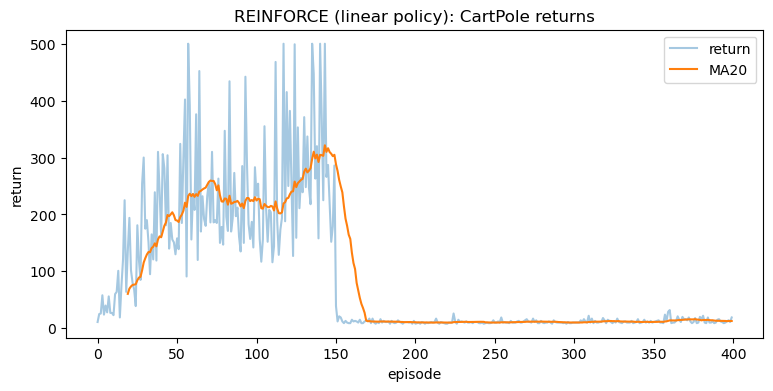

final w: [ 8.462687  -1.3510934]


In [6]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def phi(obs):
    x, xdot, th, thdot = obs
    return np.array([th, thdot], dtype=np.float32)

def compute_returns(rewards, gamma=0.99):
    G = 0.0
    out = []
    for r in reversed(rewards):
        G = r + gamma * G
        out.append(G)
    out.reverse()
    return np.array(out, dtype=np.float32)

def grad_logpi(w, features, action):
    z = float(np.dot(w, features))
    p = sigmoid(z)
    # ∇w log π(a|s) = (a - p) * phi
    return (action - p) * features, p

# --- trening ---
env = gym.make("CartPole-v1")

episodes = 400
gamma = 0.99
alpha = 0.01          # mniejsze niż w "one-shot" (stabilniej)
w = np.array([0.0, 0.0], dtype=np.float32)

returns_hist = []
baseline = 0.0
beta = 0.9            # baseline EMA: baseline = beta*baseline + (1-beta)*G0

for ep in range(episodes):
    obs, info = env.reset(seed=ep)
    phi_list, act_list, rew_list = [], [], []
    total = 0.0

    # rollout
    for t in range(500):
        features = phi(obs)
        z = float(np.dot(w, features))
        p = sigmoid(z)
        action = 1 if np.random.rand() < p else 0

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        phi_list.append(features)
        act_list.append(action)
        rew_list.append(float(reward))
        total += float(reward)

        if done:
            break

    # returns
    G = compute_returns(rew_list, gamma=gamma)

    # baseline: wykładnicza średnia zwrotu z epizodu (G0)
    baseline = beta * baseline + (1 - beta) * float(G[0])

    # policy gradient update
    grad_sum = np.zeros_like(w)
    for t in range(len(G)):
        g, p = grad_logpi(w, phi_list[t], act_list[t])
        advantage = G[t] - baseline
        grad_sum += g * advantage

    w += alpha * grad_sum

    returns_hist.append(total)

    if (ep + 1) % 50 == 0:
        avg = np.mean(returns_hist[-50:])
        print(f"ep {ep+1:4d} | avg_return(last50)={avg:6.1f} | w={w} | baseline={baseline:.1f}")

env.close()

# wykres
def moving_average(x, window=20):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.figure(figsize=(9,4))
plt.plot(returns_hist, alpha=0.4, label="return")
plt.plot(range(19, 19+len(moving_average(returns_hist, 20))), moving_average(returns_hist, 20), label="MA20")
plt.title("REINFORCE (linear policy): CartPole returns")
plt.xlabel("episode")
plt.ylabel("return")
plt.legend()
plt.show()

print("final w:", w)


## Zadanie: Ustabilizuj REINFORCE (żeby nie “rozjeżdżał się” po 200–400 epizodach)

W naszej implementacji REINFORCE widzieliśmy typowy efekt:
- przez pewien czas wyniki rosną (np. średni return ~200–300),
- a potem polityka potrafi “odjechać” i wyniki nagle spadają nawet do ~10.

Twoim zadaniem jest poprawić trening tak, aby:
1) uczenie było stabilniejsze,
2) średni return w końcówce treningu był wyższy,
3) nie dochodziło do “katastrofalnego spadku” jak w przykładzie.

### Cel ilościowy (minimum)
Po 400 epizodach:
- `avg_return(last50) ≥ 250`
- oraz brak spadku do wartości < 50 w ostatnich 100 epizodach.

### Cel ambitny
- `avg_return(last50) ≥ 400` (lub nawet blisko 500)
- stabilny przebieg (mało “szarpania”)

---

## Kontekst: co wolno zmieniać?
Nie zmieniamy środowiska ani definicji cech $\phi(s)=[\theta,\dot\theta]$.
Nie zmieniamy też faktu, że to jest policy gradient na stochastycznej polityce Bernoulli.

Możesz natomiast:
- zmienić learning rate $\alpha$,
- dodać/zmienić baseline,
- dodać normalizację advantage,
- dodać klipowanie gradientu / update,
- dodać prostą regularyzację (np. ograniczenie normy wag),
- dodać bardziej sensowny baseline (np. uczony $V(s)$ – ale to już “bonus”).

---

## Zadanie A (łatwe): dobór learning rate + stabilizacja update

### A1) Zmniejsz learning rate
Przetestuj kilka wartości:
- $\alpha \in \{0.01,\ 0.003,\ 0.001,\ 0.0003\}$

Oczekiwany efekt:
- mniejsze “szarpanie”,
- mniej ryzyka, że wagi nagle odjadą w złą stronę.

### A2) Klipowanie normy update (lub gradientu)
Zaimplementuj ograniczenie normy kroku:
- jeśli $||\Delta w|| > \text{clip}$, to przeskaluj $\Delta w$ do długości `clip`.

Przykładowy pomysł:
- `clip = 0.5` albo `1.0`.

Cel:
- uniknąć pojedynczych, katastrofalnych aktualizacji.

---

## Zadanie B (średnie): normalizacja advantage

W REINFORCE aktualizacja używa:
$$
A_t = G_t - b
$$

Zaimplementuj normalizację w obrębie epizodu:
$$
\tilde A_t = \frac{A_t - \mu_A}{\sigma_A + \epsilon}
$$

gdzie $\mu_A$ i $\sigma_A$ liczysz po wszystkich krokach epizodu.

Oczekiwany efekt:
- dużo stabilniejsze uczenie,
- mniejsza wariancja gradientu,
- mniej “katastrof”.

---

## Zadanie C (trudniejsze): lepszy baseline

W wersji podstawowej baseline to jedna liczba (EMA ze zwrotu epizodu).
Zrób baseline w jednej z dwóch wersji:

### C1) Baseline jako średnia krocząca z ostatnich K epizodów
Np. K=50.
To stabilniejsze niż EMA, gdy wyniki nagle spadają.

### C2) (BONUS) Critic: baseline zależny od stanu $V_\phi(s)$
To jest już krok w stronę Actor–Critic (A2C):
- uczysz osobny model $V(s)$ (np. małą sieć lub liniowo),
- używasz $A_t = G_t - V(s_t)$.

To zwykle daje największy wzrost stabilności.

---

## Co oddajesz?

1) Zmieniony kod (wystarczy jeden plik / notebook).
2) Wykres: return vs episode + moving average (np. MA20 lub MA50).
3) Krótki komentarz (5–10 zdań):
   - co zmieniłeś,
   - dlaczego to powinno pomagać,
   - jakie są wyniki (liczby).

---

## Wskazówka: jak rozpoznać “katastrofę”?
Typowy symptom:
- wagi nagle mają bardzo duże wartości (np. $|w|$ rośnie),
- baseline nagle spada,
- returny spadają do kilku–kilkunastu.

Twoim celem jest tak dobrać stabilizację, żeby do tego nie dochodziło.

---

## Pytania kontrolne (do refleksji)
1) Dlaczego stochastyczna polityka jest potrzebna w REINFORCE, a nie używamy twardego progu?
2) Skąd bierze się duża wariancja gradientu w REINFORCE?
3) Dlaczego baseline nie zmienia “poprawności” gradientu, ale poprawia stabilność?
4) Co jest analogią baseline w DQN (hint: target network / replay)?
